##Classification task: Classical Classification on CIFAR-10


In this section, we evaluate three classical machine learning models using the CIFAR-10 dataset:

• Multiclass Logistic Regression (Softmax)
<br>
• Linear Support Vector Machine (SVM)
<br>
• K-Nearest Neighbors (KNN)
<br>
<br>
The objective is to classify 32×32 color images into one of ten predefined classes.
<br>
 This task allows us to evaluate how classical machine learning models perform on high-dimensional image data and to understand their limitations.


In [1]:
import os
import tarfile
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier

SEED = 42
np.random.seed(SEED)

**Data Loading and Preparation**
<br>
<br>
In this section, we download the Python version of the CIFAR-10 dataset (as required), extract the dataset, and load the batch files into NumPy arrays.
<br>
The training batches are combined into a single dataset, and the corresponding labels are loaded as well.


In [2]:
# Download CIFAR-10 python version (as required)
DATA_DIR = "cifar10_data"
os.makedirs(DATA_DIR, exist_ok=True)

URL = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
TAR_PATH = os.path.join(DATA_DIR, "cifar-10-python.tar.gz")

# Download only if not already downloaded
if not os.path.exists(TAR_PATH):
    !wget -O {TAR_PATH} {URL}

# Extract only if not already extracted
EXTRACT_DIR = os.path.join(DATA_DIR, "cifar-10-batches-py")
if not os.path.exists(EXTRACT_DIR):
    with tarfile.open(TAR_PATH, "r:gz") as tar:
        tar.extractall(path=DATA_DIR)

--2026-03-10 08:11:54--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar10_data/cifar-10-python.tar.gz’

cifar10_data/cifar- 100%[===================>] 162.60M  75.5MB/s    in 2.2s    

2026-03-10 08:11:57 (75.5 MB/s) - ‘cifar10_data/cifar-10-python.tar.gz’ saved [170498071/170498071]



/tmp/ipykernel_334/1596926212.py:16: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATA_DIR)


In [3]:
# Function to load a single CIFAR-10 batch file (they are stored as pickled files)
def unpickle(file_path):
    with open(file_path, "rb") as fo:
        return pickle.load(fo, encoding="bytes")


# Function to load all CIFAR-10 training batches + test batch
def load_cifar10_batches(batches_dir):
    X_train_list, y_train_list = [], []

    # CIFAR-10 training data is split into 5 separate batch files
    for i in range(1, 6):
        batch = unpickle(os.path.join(batches_dir, f"data_batch_{i}"))
        X_train_list.append(batch[b"data"])      # image data (flattened 32x32x3)
        y_train_list.append(batch[b"labels"])   # corresponding labels

    # Combine all 5 batches into one large training set
    X_train = np.vstack(X_train_list)
    y_train = np.hstack(y_train_list)

    # Load the test batch
    test_batch = unpickle(os.path.join(batches_dir, "test_batch"))
    X_test = test_batch[b"data"]
    y_test = np.array(test_batch[b"labels"])

    # Load label names (class names like 'airplane', 'cat', etc.)
    meta = unpickle(os.path.join(batches_dir, "batches.meta"))
    label_names = [x.decode("utf-8") for x in meta[b"label_names"]]

    return X_train, y_train, X_test, y_test, label_names


# Load the dataset
X_all, y_all, X_test, y_test, label_names = load_cifar10_batches(EXTRACT_DIR)

# Check the shapes to make sure everything loaded correctly
print("Train shape:", X_all.shape)
print("Test shape:", X_test.shape)

Train shape: (50000, 3072)
Test shape: (10000, 3072)


**Train/Validation split**
<br>
<br>
We split the original training set into train and validation sets.
The validation set is used for hyperparameter tuning and model selection,
while the test set is used only once for the final evaluation.

In [4]:
# Split the full training data into train and validation sets
# We use 80% for training and 20% for validation

X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all,
    test_size=0.2,        # 20% of the data will be used for validation
    random_state=SEED,    # for reproducibility
    stratify=y_all        # keep the class distribution balanced
)

# Print shapes to make sure the split looks correct
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (40000, 3072)
Validation shape: (10000, 3072)


**3.1 Baseline Models**
<br>
<br>
In this section, we implement the baseline models required for the task.

The models considered are Multiclass Logistic Regression (Softmax), Linear Support Vector Machine (SVM), and K-Nearest Neighbors (KNN).

All models are trained on the training set using the same train/validation split and standard scaling preprocessing.

 Their performance is evaluated on the validation set using validation accuracy.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [6]:
# Dictionary to store validation accuracy results for each baseline model
# Baseline models use the default hyperparameters

# Dictionary of baseline models
models = {
    "LogReg": LogisticRegression(
        solver="lbfgs",
        max_iter=3000,
        tol=1e-3,
        random_state=SEED
    ),
    "SVM": LinearSVC(
        max_iter=1500,
        tol=1e-3,
        dual=False,
        random_state=SEED
    ),
    "KNN": KNeighborsClassifier(
        algorithm="brute",
        n_jobs=-1
    )
}

baseline_results = {}

# Train each baseline model on the training set
# and evaluate its performance on the validation set
for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)

    # Store validation accuracy
    baseline_results[name] = acc

    if name == "LogReg":
        print(f"{name:24s} | C = {model.get_params()['C']} | Val Accuracy = {acc:.4f}")
    elif name == "SVM":
        print(f"{name:24s} | C = {model.get_params()['C']} | Val Accuracy = {acc:.4f}")
    elif name == "KNN":
        print(f"{name:24s} | k = {model.get_params()['n_neighbors']} | Val Accuracy = {acc:.4f}")

# Final dictionary with all baseline validation accuracies
baseline_results

Training LogReg...
LogReg                   | C = 1.0 | Val Accuracy = 0.3732
Training SVM...
SVM                      | C = 1.0 | Val Accuracy = 0.3555
Training KNN...
KNN                      | k = 5 | Val Accuracy = 0.3289


{'LogReg': 0.3732, 'SVM': 0.3555, 'KNN': 0.3289}

**3.2 Hyperparameter Selection**

For each model, we tune one main hyperparameter using validation accuracy.

• Logistic Regression: regularization strength \(C\)

• Linear SVM - regularization strength \(C\)  

• KNN: number of neighbors \(k\)

We also include plots showing validation accuracy as a function of the hyperparameter.

Running Logistic Regression with C = 0.01 ...
Validation accuracy for C = 0.01: 0.3984

Running Logistic Regression with C = 0.1 ...
Validation accuracy for C = 0.1: 0.3845

Running Logistic Regression with C = 1 ...
Validation accuracy for C = 1: 0.3732

Running Logistic Regression with C = 10 ...
Validation accuracy for C = 10: 0.3668



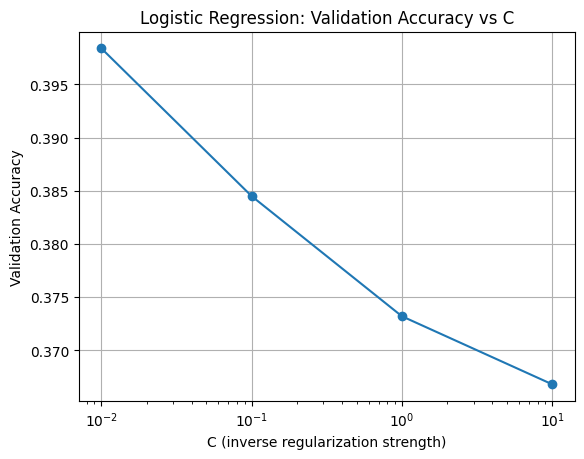

Selected C = 0.01
Best Validation Accuracy = 0.3984


In [15]:
# Logistic Regression hyperparameter tuning

# Different regularization strengths to try
C_values_lr = [0.01, 0.1, 1, 10]

lr_accs = []
best_lr = None
best_lr_C = None
best_lr_acc = -1

for C in C_values_lr:
    print(f"Running Logistic Regression with C = {C} ...")

    model = LogisticRegression(
        C=C,                 # inverse of regularization strength
        solver="lbfgs",      # good for multinomial problems
        max_iter=5000,       # allow more iterations for convergence
        tol=1e-3,            # slightly faster convergence
        random_state=SEED
    )

    # Train on the scaled training set
    model.fit(X_train_scaled, y_train)

    # Evaluate on the scaled validation set
    preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)
    lr_accs.append(acc)

    # Keep track of the best C according to validation accuracy
    if acc > best_lr_acc:
        best_lr_acc = acc
        best_lr_C = C
        best_lr = model

    print(f"Validation accuracy for C = {C}: {acc:.4f}\n")

# Plot: validation accuracy vs C
plt.figure()
plt.plot(C_values_lr, lr_accs, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Validation Accuracy")
plt.title("Logistic Regression: Validation Accuracy vs C")
plt.grid(True)
plt.show()

print("Selected C =", best_lr_C)
print("Best Validation Accuracy =", best_lr_acc)

In [6]:
# Linear SVM hyperparameter tuning
# Try different values of the regularization parameter C
# and select the best value according to validation accuracy

C_values_svm = [0.01, 0.1, 1, 10]

svm_accs = []
best_svm = None
best_svm_C = None
best_svm_acc = -1

In [7]:
C = 0.01
print(f"Running Linear SVM with C = {C} ...")

model = LinearSVC(
    C=C,
    max_iter=1500,
    tol=1e-3,
    dual=False,
    random_state=SEED
)

# Train on the scaled training set
model.fit(X_train_scaled, y_train)

# Evaluate on the scaled validation set
preds = model.predict(X_val_scaled)
acc = accuracy_score(y_val, preds)
svm_accs.append(acc)

# Keep track of the best C according to validation accuracy
if acc > best_svm_acc:
    best_svm_acc = acc
    best_svm_C = C
    best_svm = model

print(f"Validation accuracy for C = {C}: {acc:.4f}\n")

Running Linear SVM with C = 0.01 ...
Validation accuracy for C = 0.01: 0.3847



In [8]:
C = 0.1
print(f"Running Linear SVM with C = {C} ...")

model = LinearSVC(
    C=C,
    max_iter=1500,
    tol=1e-3,
    dual=False,
    random_state=SEED
)

# Train on the scaled training set
model.fit(X_train_scaled, y_train)

# Evaluate on the scaled validation set
preds = model.predict(X_val_scaled)
acc = accuracy_score(y_val, preds)
svm_accs.append(acc)

# Keep track of the best C according to validation accuracy
if acc > best_svm_acc:
    best_svm_acc = acc
    best_svm_C = C
    best_svm = model

print(f"Validation accuracy for C = {C}: {acc:.4f}\n")

Running Linear SVM with C = 0.1 ...
Validation accuracy for C = 0.1: 0.3694



In [9]:
C = 1
print(f"Running Linear SVM with C = {C} ...")

model = LinearSVC(
    C=C,
    max_iter=1500,
    tol=1e-3,
    dual=False,
    random_state=SEED
)

# Train on the scaled training set
model.fit(X_train_scaled, y_train)

# Evaluate on the scaled validation set
preds = model.predict(X_val_scaled)
acc = accuracy_score(y_val, preds)
svm_accs.append(acc)

# Keep track of the best C according to validation accuracy
if acc > best_svm_acc:
    best_svm_acc = acc
    best_svm_C = C
    best_svm = model

print(f"Validation accuracy for C = {C}: {acc:.4f}\n")

Running Linear SVM with C = 1 ...
Validation accuracy for C = 1: 0.3555



In [10]:
C = 10
print(f"Running Linear SVM with C = {C} ...")

model = LinearSVC(
    C=C,
    max_iter=1500,
    tol=1e-3,
    dual=False,
    random_state=SEED
)

# Train on the scaled training set
model.fit(X_train_scaled, y_train)

# Evaluate on the scaled validation set
preds = model.predict(X_val_scaled)
acc = accuracy_score(y_val, preds)
svm_accs.append(acc)

# Keep track of the best C according to validation accuracy
if acc > best_svm_acc:
    best_svm_acc = acc
    best_svm_C = C
    best_svm = model

print(f"Validation accuracy for C = {C}: {acc:.4f}\n")

Running Linear SVM with C = 10 ...
Validation accuracy for C = 10: 0.3523



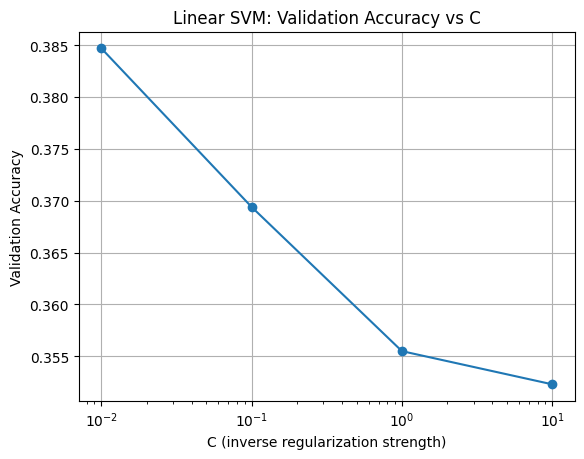

Selected C = 0.01
Best Validation Accuracy = 0.3847


In [11]:
# Plot: validation accuracy vs C
plt.figure()
plt.plot(C_values_svm, svm_accs, marker="o")
plt.xscale("log")
plt.xlabel("C (inverse regularization strength)")
plt.ylabel("Validation Accuracy")
plt.title("Linear SVM: Validation Accuracy vs C")
plt.grid(True)
plt.show()

print("Selected C =", best_svm_C)
print("Best Validation Accuracy =", best_svm_acc)

Validation accuracy for k = 1: 0.3443
Validation accuracy for k = 3: 0.3231
Validation accuracy for k = 5: 0.3289
Validation accuracy for k = 7: 0.3276
Validation accuracy for k = 9: 0.3291
Validation accuracy for k = 11: 0.3259
Validation accuracy for k = 15: 0.3259


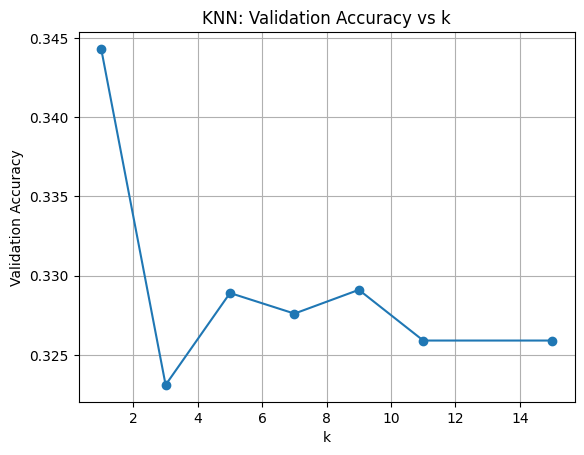

Selected k = 1
Best Validation Accuracy = 0.3443


In [16]:
# KNN hyperparameter tuning
# Try different values of k and select the best one based on validation accuracy

k_values = [1, 3, 5, 7, 9, 11, 15]

knn_accs = []        # store validation accuracies
best_knn = None      # keep best model
best_knn_k = None    # best k
best_knn_acc = -1    # best accuracy so far

for k in k_values:

    model = KNeighborsClassifier(
        n_neighbors=k,
        algorithm="brute",   # faster for high-dimensional data like CIFAR-10
        n_jobs=-1
    )

    # Train the model on the scaled training set
    model.fit(X_train_scaled, y_train)

    # Evaluate on the scaled validation set
    preds = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, preds)
    knn_accs.append(acc)

    # Update best model if current one is better
    if acc > best_knn_acc:
        best_knn_acc = acc
        best_knn_k = k
        best_knn = model

    print(f"Validation accuracy for k = {k}: {acc:.4f}")

# Plot validation accuracy vs k
plt.figure()
plt.plot(k_values, knn_accs, marker="o")
plt.xlabel("k")
plt.ylabel("Validation Accuracy")
plt.title("KNN: Validation Accuracy vs k")
plt.grid(True)
plt.show()

print("Selected k =", best_knn_k)
print("Best Validation Accuracy =", best_knn_acc)

**3.3 Evaluation and Analysis**

In this section, we evaluate the tuned models obtained in Section 3.2 (Hyperparameter Selection).
<br>

For each model, we compute the validation accuracy and generate a confusion matrix using the validation set.
<br>

After comparing the validation performance, we select the model with the highest validation accuracy. The selected model is then retrained using the combined training and validation data.
<br>

Finally, the retrained model is evaluated once on the test set to report the final test accuracy.

LogReg       | Validation Accuracy = 0.3984


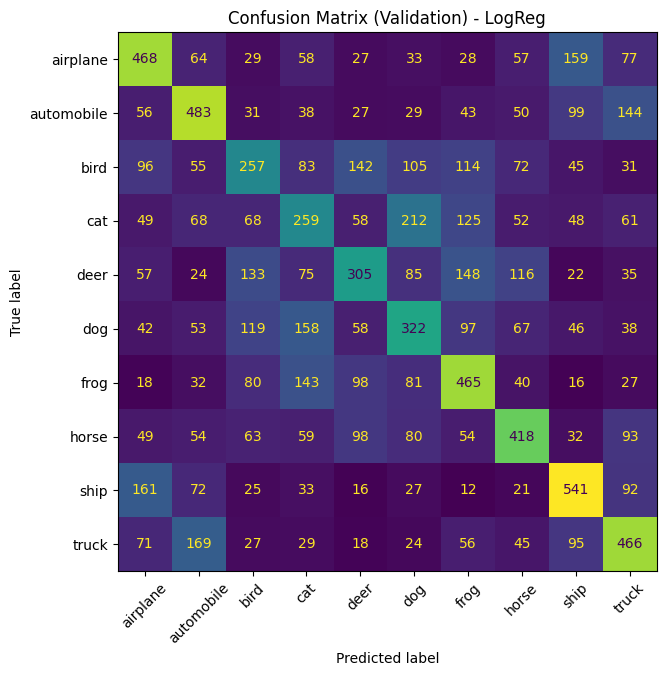

Linear SVM   | Validation Accuracy = 0.3847


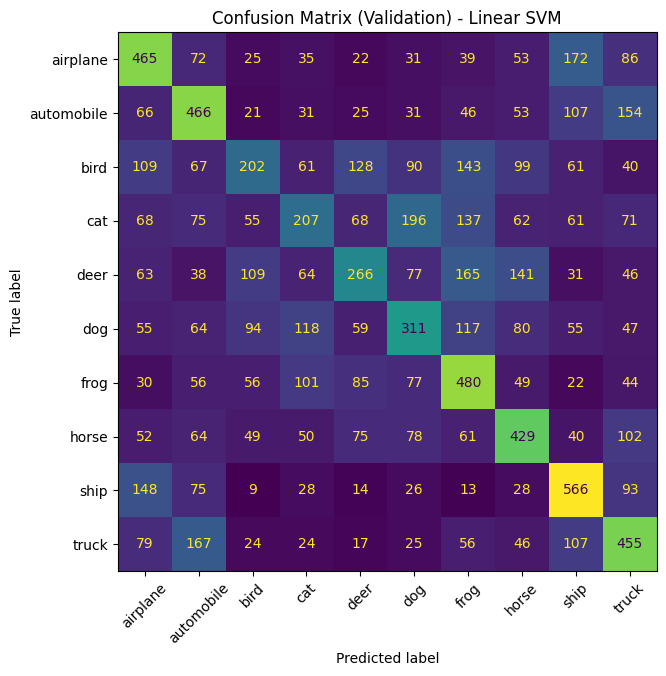

KNN          | Validation Accuracy = 0.3443


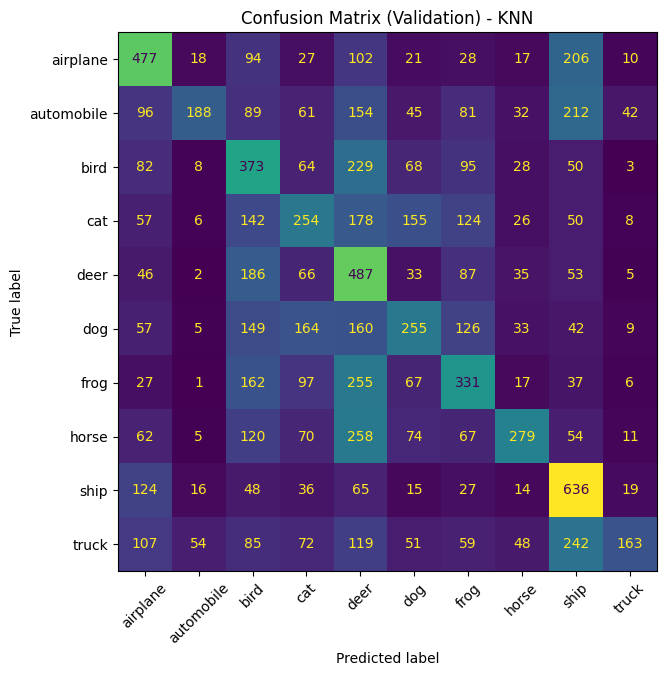

{'LogReg': 0.3984, 'Linear SVM': 0.3847, 'KNN': 0.3443}

In [17]:
# Here we evaluate the *best* version of each model (after hyperparameter tuning).
# For each model, we report:
# 1) Validation accuracy
# 2) Confusion matrix on the validation set

best_models = {
    "LogReg": best_lr,       # best Logistic Regression model (selected in Section 3.2)
    "Linear SVM": best_svm,  # best Linear SVM model (selected in Section 3.2)
    "KNN": best_knn,         # best KNN model (selected in Section 3.2)
}

val_scores = {}  # dictionary to store validation accuracy for each model

for name, model in best_models.items():
    # Predict on the scaled validation set
    preds = model.predict(X_val_scaled)

    # Compute validation accuracy
    acc = accuracy_score(y_val, preds)
    val_scores[name] = acc

    print(f"{name:12s} | Validation Accuracy = {acc:.4f}")

    # Compute the confusion matrix
    cm = confusion_matrix(y_val, preds, labels=list(range(10)))

    # Plot confusion matrix to analyze class-wise performance
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
    fig, ax = plt.subplots(figsize=(7, 7))
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
    plt.title(f"Confusion Matrix (Validation) - {name}")
    plt.show()

# Print all validation scores together for comparison
val_scores

In [18]:
# Select the final model based on validation accuracy
# Select the model with the highest validation accuracy

final_name = max(val_scores, key=val_scores.get)
final_model = best_models[final_name]

print("Selected final model:", final_name)
print("Validation accuracy:", val_scores[final_name])

# Retrain the chosen model on the combined training and validation data

X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

# Fit a new scaler on the full training data, then transform both train_full and test
final_scaler = StandardScaler()
X_train_full_scaled = final_scaler.fit_transform(X_train_full)
X_test_scaled = final_scaler.transform(X_test)

final_model.fit(X_train_full_scaled, y_train_full)

# Evaluate on the test set (used only once at the end)

test_pred = final_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, test_pred)

print("Final Test Accuracy:", test_acc)

Selected final model: LogReg
Validation accuracy: 0.3984
Final Test Accuracy: 0.397
